<a href="https://colab.research.google.com/github/Ololade117/stat4datascience/blob/main/w3n2_hypothesis_testing_pvalues.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics and Quantitative Methods for Data Science
[© Silvadew Institute](https://institute.silvadew.com/course-details/?c=43177d50)

# Lecture 6-  Hypothesis Testing, p-values & Statistical Significance
### Statistics & Quantitative Methods for Data Science

Last class we built confidence intervals — ranges of plausible values. This class asks a sharper question: **is there evidence for a specific claim**, e.g. "fare differed between survivors and non-survivors" or "gender and survival are related"?

**This notebook:**
1. The logic of hypothesis testing (H0, H1, p-values)
2. Type I & Type II errors
3. One-sample and two-sample t-tests
4. Paired t-test
5. Chi-square test of independence
6. One-way ANOVA
7. Statistical vs. practical significance
8. Exercises


## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True

TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(TITANIC_URL)
titanic.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


---
# 1. The logic of hypothesis testing

1. State a **null hypothesis** $H_0$ — the "nothing interesting is happening" baseline (e.g. "mean fare is the same for survivors and non-survivors").
2. State an **alternative hypothesis** $H_1$ — what you suspect instead (e.g. "mean fare differs").
3. Compute a **test statistic** from the data that measures how far the data is from what $H_0$ predicts.
4. Compute a **p-value**: *if $H_0$ were true, how likely is a result this extreme (or more extreme) just by random chance?*
5. Compare the p-value to a significance threshold $\alpha$ (conventionally 0.05). If $p < \alpha$, **reject $H_0$**.

**Crucial nuance**: a small p-value doesn't "prove $H_1$" — it means the data would be surprising *if $H_0$ were true*. We never "accept $H_0$" either; we only ever fail to reject it.

---
# 2. Type I & Type II errors

| | $H_0$ actually true | $H_0$ actually false |
|---|---|---|
| **Reject $H_0$** | Type I error (false positive), rate = $\alpha$ | Correct! |
| **Fail to reject $H_0$** | Correct! | Type II error (false negative), rate = $\beta$ |

**Statistical power** = $1-\beta$ = probability of correctly detecting a real effect. Power increases with larger sample sizes and larger true effect sizes.

In [ ]:
# Simulate Type I error rate directly: if H0 is TRUE (two samples really drawn from the same population),
# how often does a t-test wrongly reject H0 at alpha=0.05, just by chance?
false_positives = 0
n_sims = 2000
population = titanic['fare'].dropna().values

for i in range(n_sims):
    rng = np.random.default_rng(i)
    sample_a = rng.choice(population, size=40, replace=True)
    sample_b = rng.choice(population, size=40, replace=True)   # same population -> H0 is TRUE
    _, p = stats.ttest_ind(sample_a, sample_b)
    if p < 0.05:
        false_positives += 1

print(f"False positive rate: {false_positives/n_sims:.3f}  (should be close to alpha=0.05)")

False positive rate: 0.041  (should be close to alpha=0.05)


---
# 3. One-sample and two-sample t-tests

**One-sample t-test**: does the sample mean differ from a specific known value?
**Two-sample (independent) t-test**: do two independent groups have different means?

In [ ]:
# One-sample: was the average fare 30, historically claimed? Test against our data.
fare = titanic['fare'].dropna()
t_stat, p_val = stats.ttest_1samp(fare, popmean=30)
print(f"One-sample t-test (H0: mean fare = 30)")
print(f"t = {t_stat:.3f}, p = {p_val:.4f}")
print("Reject H0" if p_val < 0.05 else "Fail to reject H0", f"at alpha=0.05 (sample mean = {fare.mean():.2f})")

One-sample t-test (H0: mean fare = 30)
t = 1.324, p = 0.1858
Fail to reject H0 at alpha=0.05 (sample mean = 32.20)


In [ ]:
# Two-sample: did survivors pay a different average fare than non-survivors?
fare_survived = titanic.loc[titanic.survived==1, 'fare'].dropna()
fare_died     = titanic.loc[titanic.survived==0, 'fare'].dropna()

# Welch's t-test (equal_var=False) doesn't assume the two groups have equal variance -- safer default
t_stat, p_val = stats.ttest_ind(fare_survived, fare_died, equal_var=False)
print(f"Two-sample t-test: mean fare, survived vs died")
print(f"Survived mean: {fare_survived.mean():.2f}   Died mean: {fare_died.mean():.2f}")
print(f"t = {t_stat:.3f}, p = {p_val:.2e}")
print("Reject H0: fares differ significantly." if p_val < 0.05 else "Fail to reject H0.")

Two-sample t-test: mean fare, survived vs died
Survived mean: 48.40   Died mean: 22.12
t = 6.839, p = 2.70e-11
Reject H0: fares differ significantly.


/tmp/ipykernel_119/3453528103.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([fare_died, fare_survived], labels=['Died', 'Survived'])


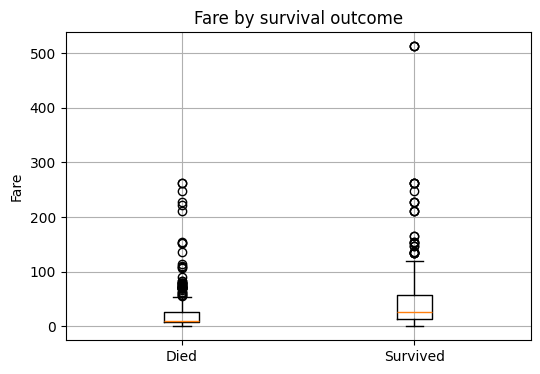

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ax.boxplot([fare_died, fare_survived], labels=['Died', 'Survived'])
ax.set_ylabel('Fare'); ax.set_title('Fare by survival outcome')
plt.show()

---
# 4. Paired t-test

Used when the same subjects are measured **twice** (before/after) — pairing controls for individual variation, giving a more sensitive test than treating the two sets as independent. Titanic has no natural "before/after" measurement, so we'll simulate a believable scenario: a training program's effect on the *same* group of students' test scores.

In [ ]:
np.random.seed(7)
n_students = 25
before = np.random.normal(65, 10, n_students)
improvement = np.random.normal(4, 5, n_students)   # a real, modest average improvement
after = before + improvement

t_stat, p_val = stats.ttest_rel(after, before)
print(f"Mean before: {before.mean():.2f}   Mean after: {after.mean():.2f}   Mean diff: {(after-before).mean():.2f}")
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
print("Reject H0: the training had a significant effect." if p_val < 0.05 else "Fail to reject H0.")

Mean before: 65.53   Mean after: 68.33   Mean diff: 2.80
Paired t-test: t = 2.259, p = 0.0332
Reject H0: the training had a significant effect.


---
# 5. Chi-square test of independence

Used for **two categorical variables**: are they associated, or independent? Compares observed counts in a contingency table to the counts we'd *expect* if the variables were unrelated.

$$\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$$

In [ ]:
contingency = pd.crosstab(titanic['sex'], titanic['survived'])
print("Observed counts:")
print(contingency)

chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square = {chi2:.2f}, dof = {dof}, p = {p_val:.2e}")
print("\nExpected counts under independence:")
print(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns).round(1))
print("\nReject H0: sex and survival are significantly associated." if p_val < 0.05 else "Fail to reject H0.")

Observed counts:
survived    0    1
sex               
female     81  233
male      468  109

Chi-square = 260.72, dof = 1, p = 1.20e-58

Expected counts under independence:
survived      0      1
sex                   
female    193.5  120.5
male      355.5  221.5

Reject H0: sex and survival are significantly associated.


In [ ]:
# Another one: is passenger class associated with embarkation town?
ct2 = pd.crosstab(titanic['pclass'], titanic['embark_town'])
chi2, p_val, dof, expected = stats.chi2_contingency(ct2)
print(f"Chi-square = {chi2:.2f}, dof = {dof}, p = {p_val:.2e}")
print("Class and embarkation town are significantly associated." if p_val < 0.05 else "No significant association.")

Chi-square = 123.75, dof = 4, p = 8.44e-26
Class and embarkation town are significantly associated.


---
# 6. One-way ANOVA

t-tests compare **two** group means. When comparing **three or more** groups at once, use **ANOVA** (Analysis of Variance) — it tests whether *at least one* group mean differs, without inflating the false-positive rate the way running many pairwise t-tests would.

$H_0$: all group means are equal. $H_1$: at least one differs.

In [ ]:
fare_by_class = [titanic.loc[titanic.pclass==c, 'fare'].dropna() for c in [1,2,3]]

f_stat, p_val = stats.f_oneway(*fare_by_class)
print(f"F-statistic = {f_stat:.2f}, p = {p_val:.2e}")
print("Reject H0: mean fare differs significantly across at least one class." if p_val < 0.05 else "Fail to reject H0.")

for c, f in zip([1,2,3], fare_by_class):
    print(f"  Class {c}: mean fare = {f.mean():.2f}, n = {len(f)}")

F-statistic = 242.34, p = 1.03e-84
Reject H0: mean fare differs significantly across at least one class.
  Class 1: mean fare = 84.15, n = 216
  Class 2: mean fare = 20.66, n = 184
  Class 3: mean fare = 13.68, n = 491


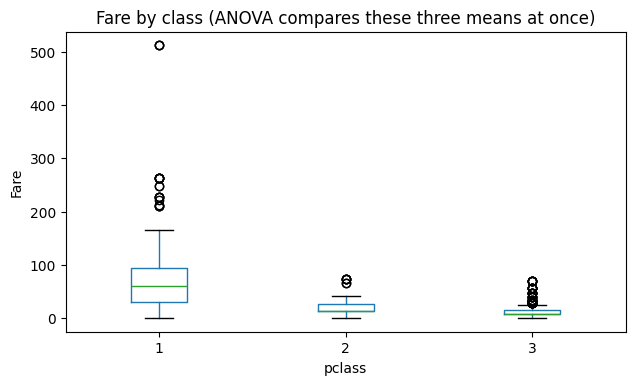

In [ ]:
titanic.boxplot(column='fare', by='pclass', grid=False)
plt.title('Fare by class (ANOVA compares these three means at once)')
plt.suptitle(''); plt.ylabel('Fare')
plt.show()

> ANOVA tells you *that* a difference exists somewhere, but not *which* pairs differ. Follow-up "post-hoc" tests (e.g. Tukey's HSD) are used to pin that down — worth looking into if this comes up in your own analyses.

---
# 7. Statistical vs. practical significance

A result can be **statistically significant** (very unlikely under $H_0$) yet **practically trivial** — especially with large sample sizes, where even a tiny, uninteresting difference can produce a tiny p-value. Always report and think about the **effect size**, not just the p-value.

In [ ]:
# Demonstrate: with a huge sample, even a trivially small difference becomes "significant"
np.random.seed(0)
group_a = np.random.normal(50.0, 10, 100_000)
group_b = np.random.normal(50.1, 10, 100_000)   # a difference of 0.1 -- practically meaningless

t_stat, p_val = stats.ttest_ind(group_a, group_b)
print(f"Mean difference: {group_b.mean()-group_a.mean():.3f}")
print(f"t = {t_stat:.3f}, p = {p_val:.4f}")
print("'Significant' by p-value, but is a 0.1-unit difference practically meaningful? Almost certainly not.")

# Effect size: Cohen's d puts the difference in units of standard deviation
pooled_std = np.sqrt((group_a.std()**2 + group_b.std()**2) / 2)
cohens_d = (group_b.mean() - group_a.mean()) / pooled_std
print(f"Cohen's d = {cohens_d:.4f}  (by convention: 0.2=small, 0.5=medium, 0.8=large -- this is negligible)")

Mean difference: 0.135
t = -3.028, p = 0.0025
'Significant' by p-value, but is a 0.1-unit difference practically meaningful? Almost certainly not.
Cohen's d = 0.0135  (by convention: 0.2=small, 0.5=medium, 0.8=large -- this is negligible)


---
# 8. Exercises

1. Run a one-sample t-test on `age`, testing $H_0$: mean age = 30. State your conclusion.
2. Run a two-sample t-test comparing `age` between 1st class and 3rd class passengers. Are they significantly different?
3. Build a contingency table of `survived` vs `pclass` and run a chi-square test. State the conclusion in plain English.
4. Run a one-way ANOVA comparing `age` across the three `pclass` groups. Which class has the highest mean age?
5. Compute Cohen's d for the fare difference between survivors and non-survivors (Section 3). Is the statistically significant difference also a practically large one?
6. **Challenge**: Simulate the Type II error rate (rather than Type I): draw `sample_a` and `sample_b` from populations with a genuinely different mean (e.g. shift `sample_b` by +5), and see how often the t-test *fails* to detect it at `n=10` vs `n=100`. What does this tell you about statistical power and sample size?
